In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from helpr.physics.pipe import Pipe
from helpr.physics.crack_initiation import DefectSpecification
from helpr.physics.environment import EnvironmentSpecification
from helpr.physics.material import MaterialSpecification
from helpr.physics.stress_state import InternalAxialHoopStress
from helpr.physics.crack_growth import CrackGrowth

in2m = 0.0254
plt.style.use('tableau-colorblind10')

In [3]:
# Material and environment class definition (constant across all cases)
max_pressure = 1
min_pressure = 1
temperature = 300
fracture_resistance = 55
yield_strength = 670
material = MaterialSpecification(yield_strength=yield_strength,
                                 fracture_resistance=fracture_resistance)
environment = EnvironmentSpecification(max_pressure=max_pressure,
                                       min_pressure=min_pressure,
                                       temperature=temperature,
                                       volume_fraction_h2=0)
phi_samples = np.linspace(0, np.pi/2, 50)

### Test Case 1 : Varying a/t. Crack depths from 10% to 80% of the wall thickness

In [4]:
d = 2 # inches
t = 0.05 # inches
a_over_t = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

KI_all = {}
KI_all_anderson = {}
for a_t in a_over_t:
    a = a_t * t
    c = 6.5*a
    KI = []
    for phi in phi_samples:
        pipe1 = Pipe(outer_diameter=d*in2m,
                     wall_thickness=t*in2m)
        defect1 = DefectSpecification(flaw_depth=a*in2m,
                                      flaw_length=2*c*in2m,
                                      surface='inside')
        hoop_stress = InternalAxialHoopStress(pipe1, environment, material, defect1, 'api')

        ki, _, _, _ = hoop_stress.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                               crack_length=2*c*in2m,
                                                               phi=phi)
        KI.append(ki)

    hoop_stress_anderson = InternalAxialHoopStress(pipe1, environment, material, defect1, 'anderson')
    KI_anderson, _, _, _ = hoop_stress_anderson.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                                             crack_length=2*c*in2m)
    KI_all[a_t] = KI
    KI_all_anderson[a_t] = KI_anderson

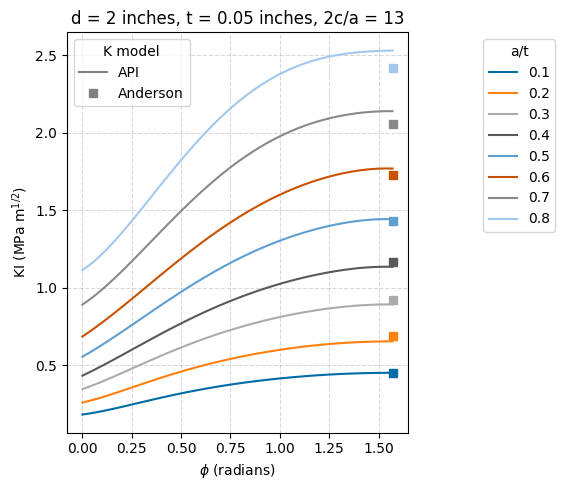

In [5]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

fig, ax = plt.subplots(figsize=(6, 5))
line1, = plt.plot([], [], linestyle='-', color='gray', label='API')
line2, = plt.plot([], [], linestyle='None', marker='s', color='gray', label='Anderson')
first_legend = ax.legend(handles=[line1, line2], loc='upper left', title='K model')
ax.add_artist(first_legend)

lines = []
for i, a_t in enumerate(a_over_t):
    line, = plt.plot(phi_samples, KI_all[a_t], linestyle='-', color=colors[i], label=a_t)
    plt.plot(np.pi/2, KI_all_anderson[a_t], marker='s', color=colors[i])
    lines.append(line)

plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.xlabel('$\phi$ (radians)')
plt.ylabel('KI (MPa m$^{1/2}$)')
ax.legend(handles=lines, bbox_to_anchor=(1.2, 1), loc='upper left', title='a/t')
plt.title(f'd = {d} inches, t = {t} inches, 2c/a = 13')

plt.tight_layout();

### Test Case 2 : Varying 2c/a between 2 and 24
#### With a/t=0.1, a/t=0.5, and a/t=0.8

In [6]:
d = 2 # inches
t = 0.05 # inches
a_over_t = 0.1
c_space = np.linspace(1, 12, 10)

KI_all = {}
KI_all_anderson = {}
for c_val in c_space:
    a = a_over_t * t
    c = c_val * a
    KI = []
    for phi in phi_samples:
        pipe1 = Pipe(outer_diameter=d*in2m,
                     wall_thickness=t*in2m)
        defect1 = DefectSpecification(flaw_depth=a*in2m,
                                      flaw_length=2*c*in2m)
        hoop_stress = InternalAxialHoopStress(pipe1, environment, material, defect1, 'api')

        ki, _, _, _ = hoop_stress.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                               crack_length=2*c*in2m,
                                                               phi=phi)
        KI.append(ki)

    hoop_stress_anderson = InternalAxialHoopStress(pipe1, environment, material, defect1, 'anderson')
    KI_anderson, _, _, _ = hoop_stress_anderson.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                                             crack_length=2*c*in2m)
    KI_all[c_val] = KI
    KI_all_anderson[c_val] = KI_anderson

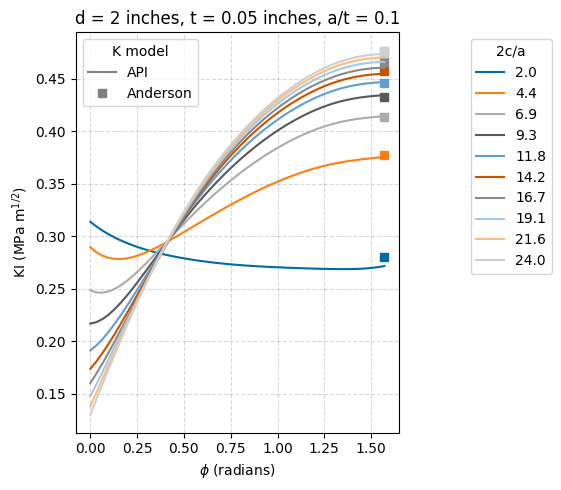

In [7]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

fig, ax = plt.subplots(figsize=(6, 5))
line1, = plt.plot([], [], linestyle='-', color='gray', label='API')
line2, = plt.plot([], [], linestyle='None', marker='s', color='gray', label='Anderson')
first_legend = ax.legend(handles=[line1, line2], loc='upper left', title='K model')
ax.add_artist(first_legend)

lines = []
for i, c in enumerate(c_space):
    line, = plt.plot(phi_samples, KI_all[c], linestyle='-', color=colors[i], label=f'{c*2:.1f}')
    plt.plot(np.pi/2, KI_all_anderson[c], marker='s', color=colors[i])
    lines.append(line)

plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.xlabel('$\phi$ (radians)')
plt.ylabel('KI (MPa m$^{1/2}$)')
ax.legend(handles=lines, bbox_to_anchor=(1.2, 1), loc='upper left', title='2c/a')
plt.title(f'd = {d} inches, t = {t} inches, a/t = {a_over_t}')

plt.tight_layout();

In [8]:
d = 2 # inches
t = 0.05 # inches
a_over_t = 0.5

KI_all = {}
KI_all_anderson = {}
for c_val in c_space:
    a = a_over_t * t
    c = c_val * a
    KI = []
    for phi in phi_samples:
        pipe1 = Pipe(outer_diameter=d*in2m,
                     wall_thickness=t*in2m)
        defect1 = DefectSpecification(flaw_depth=a*in2m,
                                      flaw_length=2*c*in2m)
        hoop_stress = InternalAxialHoopStress(pipe1, environment, material, defect1, 'api')

        ki, _, _, _ = hoop_stress.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                               crack_length=2*c*in2m,
                                                               phi=phi)
        KI.append(ki)

    hoop_stress_anderson = InternalAxialHoopStress(pipe1, environment, material, defect1, 'anderson')
    KI_anderson, _, _, _ = hoop_stress_anderson.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                                             crack_length=2*c*in2m)
    KI_all[c_val] = KI
    KI_all_anderson[c_val] = KI_anderson

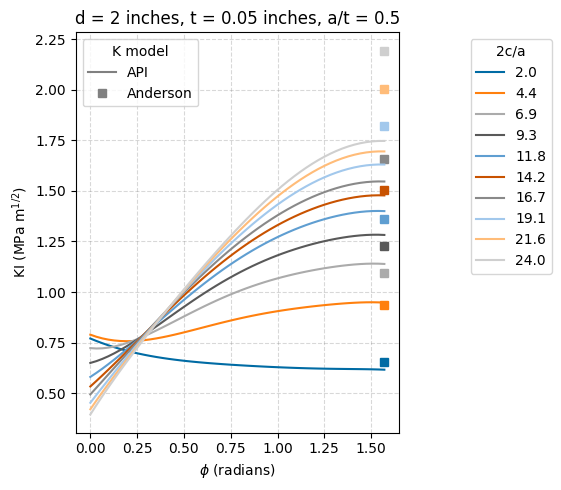

In [9]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

fig, ax = plt.subplots(figsize=(6, 5))
line1, = plt.plot([], [], linestyle='-', color='gray', label='API')
line2, = plt.plot([], [], linestyle='None' , marker='s', color='gray', label='Anderson')
first_legend = ax.legend(handles=[line1, line2], loc='upper left', title='K model')
ax.add_artist(first_legend)

lines = []
for i, c in enumerate(c_space):
    line, = plt.plot(phi_samples, KI_all[c], linestyle='-', color=colors[i], label=f'{c*2:.1f}')
    plt.plot(np.pi/2, KI_all_anderson[c], marker='s', color=colors[i])
    lines.append(line)

plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.xlabel('$\phi$ (radians)')
plt.ylabel('KI (MPa m$^{1/2}$)')
ax.legend(handles=lines, bbox_to_anchor=(1.2, 1), loc='upper left', title='2c/a')
plt.title(f'd = {d} inches, t = {t} inches, a/t = {a_over_t}')

plt.tight_layout();

In [10]:
d = 2 # inches
t = 0.05 # inches
a_over_t = 0.8

KI_all = {}
KI_all_anderson = {}
for c_val in c_space:
    a = a_over_t * t
    c = c_val * a
    KI = []
    for phi in phi_samples:
        pipe1 = Pipe(outer_diameter=d*in2m,
                     wall_thickness=t*in2m)
        defect1 = DefectSpecification(flaw_depth=a*in2m,
                                      flaw_length=2*c*in2m)
        hoop_stress = InternalAxialHoopStress(pipe1, environment, material, defect1, 'api')

        ki, _, _, _ = hoop_stress.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                               crack_length=2*c*in2m,
                                                               phi=phi)
        KI.append(ki)

    hoop_stress_anderson = InternalAxialHoopStress(pipe1, environment, material, defect1, 'anderson')
    KI_anderson, _, _, _ = hoop_stress_anderson.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                                             crack_length=2*c*in2m)
    KI_all[c_val] = KI
    KI_all_anderson[c_val] = KI_anderson

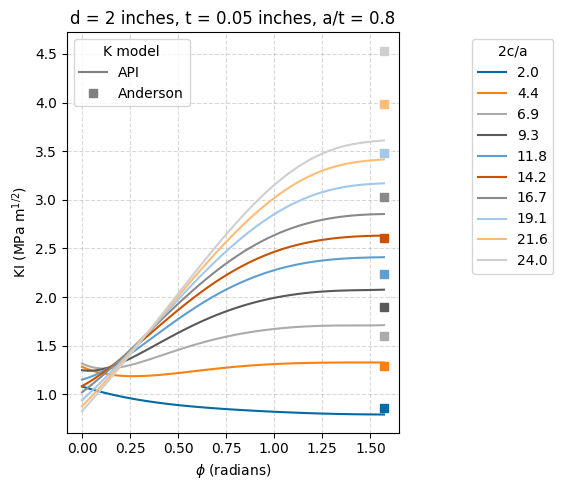

In [11]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

fig, ax = plt.subplots(figsize=(6, 5))
line1, = plt.plot([], [], linestyle='-', color='gray', label='API')
line2, = plt.plot([], [], linestyle='None', marker='s', color='gray', label='Anderson')
first_legend = ax.legend(handles=[line1, line2], loc='upper left', title='K model')
ax.add_artist(first_legend)

lines = []
for i, c in enumerate(c_space):
    line, = plt.plot(phi_samples, KI_all[c], linestyle='-', color=colors[i], label=f'{c*2:.1f}')
    plt.plot(np.pi/2, KI_all_anderson[c], marker='s', color=colors[i])
    lines.append(line)

plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.xlabel('$\phi$ (radians)')
plt.ylabel('KI (MPa m$^{1/2}$)')
ax.legend(handles=lines, bbox_to_anchor=(1.2, 1), loc='upper left', title='2c/a')
plt.title(f'd = {d} inches, t = {t} inches, a/t = {a_over_t}')

plt.tight_layout();

### Test Case 3 : Varying t from 0.02 to 0.05
#### With a/t=0.1, a/t=0.5, and a/t=0.8

In [12]:
d = 2 # inches
t_space = np.linspace(0.02, 0.05, 10) # inches
a_over_t = 0.1
c_mult = 6.5

KI_all = {}
KI_all_anderson = {}
for t in t_space:
    a = a_over_t * t
    c = c_mult * a
    KI = []
    for phi in phi_samples:
        pipe1 = Pipe(outer_diameter=d*in2m,
                     wall_thickness=t*in2m)
        defect1 = DefectSpecification(flaw_depth=a*in2m,
                                      flaw_length=2*c*in2m)
        hoop_stress = InternalAxialHoopStress(pipe1, environment, material, defect1, 'api')

        ki, _, _, _ = hoop_stress.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                               crack_length=2*c*in2m,
                                                               phi=phi)
        KI.append(ki)

    hoop_stress_anderson = InternalAxialHoopStress(pipe1, environment, material, defect1, 'anderson')
    KI_anderson, _, _, _ = hoop_stress_anderson.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                                             crack_length=2*c*in2m)
    KI_all[t] = KI
    KI_all_anderson[t] = KI_anderson

/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 48.99999999999999, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +
/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 41.857142857142854, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +
/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 36.5, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +
/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 32.3333

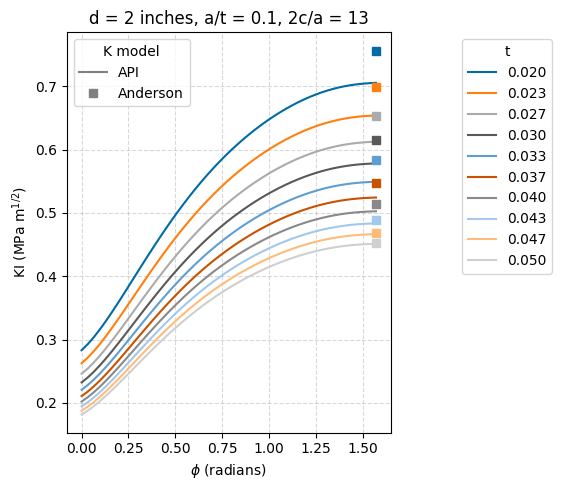

In [13]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

fig, ax = plt.subplots(figsize=(6, 5))
line1, = plt.plot([], [], linestyle='-', color='gray', label='API')
line2, = plt.plot([], [], linestyle='None', marker='s', color='gray', label='Anderson')
first_legend = ax.legend(handles=[line1, line2], loc='upper left', title='K model')
ax.add_artist(first_legend)

lines = []
for i, t in enumerate(t_space):
    line, = plt.plot(phi_samples, KI_all[t], linestyle='-', color=colors[i], label=f'{t:.3f}')
    plt.plot(np.pi/2, KI_all_anderson[t], marker='s', color=colors[i])
    lines.append(line)

plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.xlabel('$\phi$ (radians)')
plt.ylabel('KI (MPa m$^{1/2}$)')
ax.legend(handles=lines, bbox_to_anchor=(1.2, 1), loc='upper left', title='t')
plt.title(f'd = 2 inches, a/t = 0.1, 2c/a = 13')

plt.tight_layout();

In [14]:
a_over_t = 0.5
c_mult = 6.5

KI_all = {}
KI_all_anderson = {}
for t in t_space:
    a = a_over_t * t
    c = c_mult * a
    KI = []
    for phi in phi_samples:
        pipe1 = Pipe(outer_diameter=d*in2m,
                     wall_thickness=t*in2m)
        defect1 = DefectSpecification(flaw_depth=a*in2m,
                                      flaw_length=2*c*in2m)
        hoop_stress = InternalAxialHoopStress(pipe1, environment, material, defect1, 'api')

        ki, _, _, _ = hoop_stress.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                            crack_length=2*c*in2m,
                                                            phi=phi)
        KI.append(ki)

    hoop_stress_anderson = InternalAxialHoopStress(pipe1, environment, material, defect1, 'anderson')
    KI_anderson, _, _, _ = hoop_stress_anderson.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                                          crack_length=2*c*in2m)
    KI_all[t] = KI
    KI_all_anderson[t] = KI_anderson

/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 48.99999999999999, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +
/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 41.857142857142854, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +
/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 36.5, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +
/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 32.3333

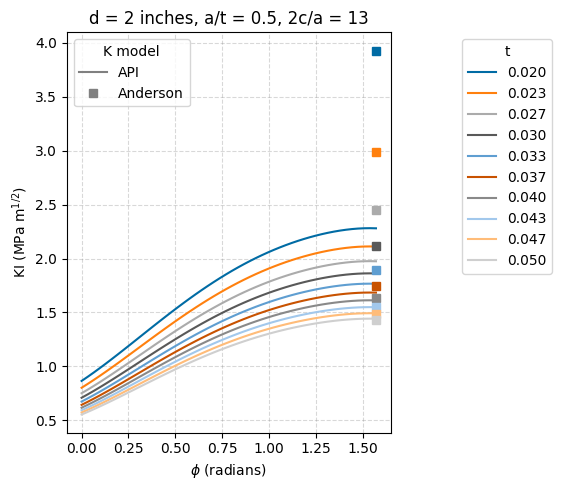

In [15]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

fig, ax = plt.subplots(figsize=(6, 5))
line1, = plt.plot([], [], linestyle='-', color='gray', label='API')
line2, = plt.plot([], [], linestyle='None', marker='s', color='gray', label='Anderson')
first_legend = ax.legend(handles=[line1, line2], loc='upper left', title='K model')
ax.add_artist(first_legend)

lines = []
for i, t in enumerate(t_space):
    line, = plt.plot(phi_samples, KI_all[t], linestyle='-', color=colors[i], label=f'{t:.3f}')
    plt.plot(np.pi/2, KI_all_anderson[t], marker='s', color=colors[i])
    lines.append(line)

plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.xlabel('$\phi$ (radians)')
plt.ylabel('KI (MPa m$^{1/2}$)')
ax.legend(handles=lines, bbox_to_anchor=(1.2, 1), loc='upper left', title='t')
plt.title(f'd = 2 inches, a/t = {a_over_t:.1f}, 2c/a = 13')

plt.tight_layout();

In [16]:
a_over_t = 0.8
c_mult = 6

KI_all = {}
KI_all_anderson = {}
for t in t_space:
    a = a_over_t * t
    c = c_mult * a
    KI = []
    for phi in phi_samples:
        pipe1 = Pipe(outer_diameter=d*in2m,
                     wall_thickness=t*in2m)
        defect1 = DefectSpecification(flaw_depth=a*in2m,
                                      flaw_length=2*c*in2m)
        hoop_stress = InternalAxialHoopStress(pipe1, environment, material, defect1, 'api')

        ki, _, _, _ = hoop_stress.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                            crack_length=2*c*in2m,
                                                            phi=phi)
        KI.append(ki)

    hoop_stress_anderson = InternalAxialHoopStress(pipe1, environment, material, defect1, 'anderson')
    KI_anderson, _, _, _ = hoop_stress_anderson.calc_stress_intensity_factor(crack_depth=a*in2m,
                                                                          crack_length=2*c*in2m)
    KI_all[t] = KI
    KI_all_anderson[t] = KI_anderson

/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 48.99999999999999, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +
/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 41.857142857142854, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +
/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 36.5, violating Anderson solution limits.
  wr.warn('Inner Radius / wall thickness exceeds bounds ' +
/Users/bbschro/Development/helpr_external/src/helpr/physics/stress_state.py:521: UserWarning: Inner Radius / wall thickness exceeds bounds 5 <= R_i/t <= 20, R_i/t = 32.3333

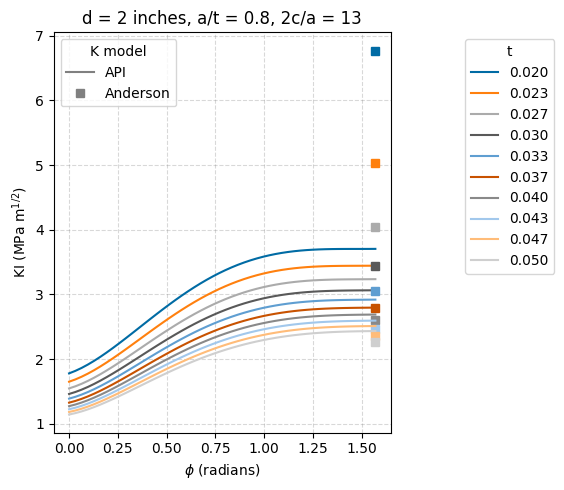

In [17]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

fig, ax = plt.subplots(figsize=(6, 5))
line1, = plt.plot([], [], linestyle='-', color='gray', label='API')
line2, = plt.plot([], [], linestyle='None', marker='s', color='gray', label='Anderson')
first_legend = ax.legend(handles=[line1, line2], loc='upper left', title='K model')
ax.add_artist(first_legend)

lines = []
for i, t in enumerate(t_space):
    line, = plt.plot(phi_samples, KI_all[t], linestyle='-', color=colors[i], label=f'{t:.3f}')
    plt.plot(np.pi/2, KI_all_anderson[t], marker='s', color=colors[i])
    lines.append(line)

plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.xlabel('$\phi$ (radians)')
plt.ylabel('KI (MPa m$^{1/2}$)')
ax.legend(handles=lines, bbox_to_anchor=(1.2, 1), loc='upper left', title='t')
plt.title(f'd = 2 inches, a/t = {a_over_t:.1f}, 2c/a = 13')

plt.tight_layout();